<a href="https://colab.research.google.com/github/Shubz15/Machine-Learning-Training/blob/main/Exp_7/Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
data = pd.read_csv("loan_approval_dataset.csv")
print("First 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns)
print("\nDataset Shape:")
print(data.shape)

First 5 rows:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0           

In [4]:


le = LabelEncoder()
data[' education'] = le.fit_transform(data[' education'])
data[' self_employed'] = le.fit_transform(data[' self_employed'])
data[' loan_status'] = le.fit_transform(data[' loan_status'])
print("After Encoding:")
print(data.head())

After Encoding:
   loan_id   no_of_dependents   education   self_employed   income_annum  \
0        1                  2           0               0        9600000   
1        2                  0           1               1        4100000   
2        3                  3           0               0        9100000   
3        4                  3           0               0        8200000   
4        5                  5           1               1        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  176

In [5]:
data = data.drop('loan_id', axis=1)
print("Columns after dropping loan_id:")
print(data.columns)


Columns after dropping loan_id:
Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [6]:
X = data.drop(' loan_status', axis=1)
Y = data[' loan_status']
print("Features (X):")
print(X.head())
print("\nTarget (Y):")
print(Y.head())

Features (X):
   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0    

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
 X, Y, test_size=0.2, random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3415, 11)
Testing Data Shape: (854, 11)


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("After Scaling (Sample):")
print(X_train[:5])

After Scaling (Sample):
[[ 1.51250774  1.00263891 -1.01504731  1.00950021  1.62477248 -0.86000338
  -0.18740061 -0.25538429  2.04678575  0.07808278  1.16041374]
 [-1.43500078  1.00263891  0.98517575  1.61417128  2.07712843  0.1888936
   0.63739678  2.49569299  1.22311091  2.49843196  0.88201987]
 [-0.84549907 -0.99736803 -1.01504731 -1.51589075 -1.35415691 -0.51037106
   0.47476068 -0.80559975 -0.8818359  -1.33923881 -1.31419838]
 [-0.25599737 -0.99736803  0.98517575 -0.05756639 -0.22878359  1.23779058
   0.8929678   0.11142601 -0.37847906  0.14349763  0.69642396]
 [ 1.51250774 -0.99736803  0.98517575 -0.73337524 -0.44944502  0.1888936
  -0.92507151  0.1572773  -0.56151791 -0.85952996 -0.91207391]]


In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)
print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [10]:
y_pred = knn_model.predict(X_test)
print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[1 1 1 0 0 0 0 1 0 1]


In [11]:
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Accuracy: 0.892271662763466

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       536
           1       0.84      0.88      0.86       318

    accuracy                           0.89       854
   macro avg       0.88      0.89      0.89       854
weighted avg       0.89      0.89      0.89       854



Note: Different colors represent different classes (0=Approved, 1=Rejected)


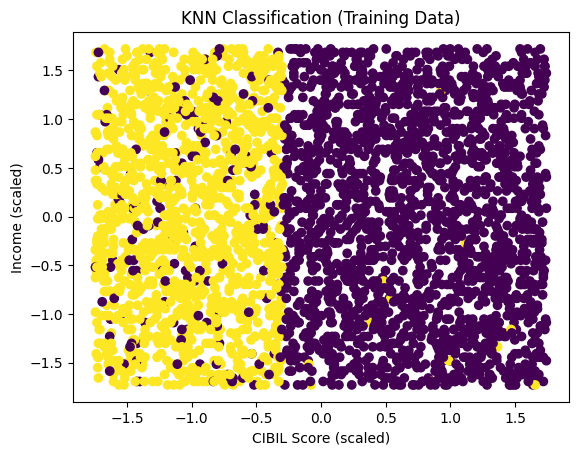

In [12]:
import matplotlib.pyplot as plt
# Select only 2 features
X_vis = data[[' cibil_score', ' income_annum']]
Y_vis = data[' loan_status']
X_train_v, X_test_v, Y_train_v, Y_test_v = train_test_split(
 X_vis, Y_vis, test_size=0.2, random_state=42
)
scaler_v = StandardScaler()
X_train_v = scaler_v.fit_transform(X_train_v)
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_v, Y_train_v)
print("Note: Different colors represent different classes (0=Approved, 1=Rejected)")
plt.figure()
plt.scatter(X_train_v[:, 0], X_train_v[:, 1], c=Y_train_v)
plt.xlabel("CIBIL Score (scaled)")
plt.ylabel("Income (scaled)")
plt.title("KNN Classification (Training Data)")
plt.show()


In [13]:
new_data = [[2, 0, 0, 5000000, 15000000, 10, 750, 3000000, 2000000, 10000000, 4000000]]
new_data_df = pd.DataFrame(new_data, columns=X.columns)
new_data_scaled = scaler.transform(new_data_df)
prediction = knn_model.predict(new_data_scaled)
print("Prediction (0=Approved, 1=Rejected):", prediction[0])

Prediction (0=Approved, 1=Rejected): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


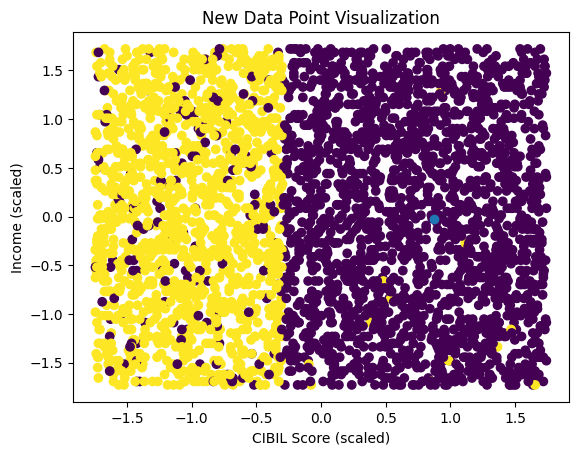

In [14]:
# New data (only 2 features: cibil_score, income_annum)
new_point = [[750, 5000000]]
new_point_scaled = scaler_v.transform(new_point)
plt.figure()
# Existing data
plt.scatter(X_train_v[:, 0], X_train_v[:, 1], c=Y_train_v)
# New point
plt.scatter(new_point_scaled[0][0], new_point_scaled[0][1])
plt.xlabel("CIBIL Score (scaled)")
plt.ylabel("Income (scaled)")
plt.title("New Data Point Visualization")
plt.show()

In [15]:
new_data = [[2, 0, 0, 5000000, 15000000, 10, 750, 3000000, 2000000, 10000000, 4000000]]
new_data_df = pd.DataFrame(new_data, columns=X.columns)
new_data_scaled = scaler.transform(new_data_df)
prediction = knn_model.predict(new_data_scaled)
print("Prediction (0=Approved, 1=Rejected):", prediction[0])
#Get K Nearest Neighbours in Code
distances, indices = knn_model.kneighbors(new_data_scaled)
print("Distances:", distances)
print("Indices:", indices)

Prediction (0=Approved, 1=Rejected): 0
Distances: [[1.21083854 1.23192837 1.29155998 1.31200493 1.38496426]]
Indices: [[1312 1436 1082 1177 2443]]
